# Mini-Project 3

**Student:** *Kim Concepcion Nielsen*

**Course:** *Numerical Scientific Computing 2026*

---

## Link to GitHub repository
[GitHub Repository Link](https://github.com/NDS8-TCP/nsc-kim.git)

## Hardware Specs
* CPU Model: Quad-Core Intel Core i7
* CPU Cores: 4
* RAM: 16GB
* L2-buffer per core: 256 kB
* L3-buffer: 8 MB

## Operating System Information
* System version: macOS 13.7.8 (22H730)

## Library versions
* Python: 3.11.14

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 1.26.4 |
| numba      | 0.63.1 |
| matplotlib | 3.10.8 |
| line_profiler  | 5.0.2  |
| memory_profiler| 0.61.0 |

### Measurement Methodology
...

---

# Computer Arithmetic

## Exercises

##### Exercise 1: Machine Epsilon

In [23]:
import numpy as np

def find_machine_epsilon(dtype):    
    eps = dtype(1.0)
    while dtype(1.0) + eps / dtype(2.0) != dtype(1.0):
        eps = eps / dtype(2.0)
    return eps

for dtype in [np.float16, np.float32, np.float32]:
    computed_eps = find_machine_epsilon(dtype)
    np_eps = np.finfo(dtype).eps
    
    print(f'{dtype.__name__}:')
    print(f'    Computed: {float(computed_eps):4e}')
    print(f'    np.fino: {float(np_eps):4e}')
    print()


float16:
    Computed: 9.765625e-04
    np.fino: 9.765625e-04

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07

float32:
    Computed: 1.192093e-07
    np.fino: 1.192093e-07



##### Exercise 2: Catastrophic Cancelation

In [ ]:
import numpy as np

def quadratic_naive(a, b, c):
    t = type(a) # np.float32 or np.float64
    disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
    x1 = (-b + disc) / (t(2)*a)
    x2 = (-b - disc) / (t(2)*a)
    return x1, x2

def quadratic_stable(a, b, c):
    t = type(a)
    disc = t(np.sqrt(b*b - t(4)*a*c))
    if b > 0:
        x1 = (-b - disc) / (t(2)*a) # pick sign that avoids cancellation
    else:
        x1 = (-b + disc) / (t(2)*a)
    x2 = c / (a * x1) # Vieta’s formula: x1 * x2 = c/a
    return x1, x2

true_small = 1.0 / 10000.0001 # ~ 1e-4

for dtype in [np.float16, np.float32, np.float64]:
    a, b, c = dtype(1.0), dtype(-10000.0001), dtype(1.0)
    _, x2_naive = quadratic_naive(a, b, c)
    _, x2_stable = quadratic_stable(a, b, c)
    err_naive = abs(float(x2_naive) - true_small) / true_small
    err_stable = abs(float(x2_stable) - true_small) / true_small
    print(f"{dtype.__name__}: naive={err_naive:.2e} stable={err_stable:.2e}")


float16: naive=inf stable=1.00e+00
float32: naive=1.00e+00 stable=1.53e-08
float64: naive=1.20e-08 stable=1.00e-08


/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:5: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c)) # b*b not b**2; t() casts literals and sqrt
/var/folders/v2/99ntmfk90bb_y5jznq4rq7f40000gn/T/ipykernel_43697/394785883.py:12: RuntimeWarning: overflow encountered in scalar multiply
  disc = t(np.sqrt(b*b - t(4)*a*c))


##### Exercise 3: Error Accumulation

In [ ]:
import numpy as np

n_values = [10, 100, 1_000, 10_000, 100_000]

for dtype in [np.float16, np.float32, np.float64]:
    print(f"\n{dtype.__name__}:")
    for n in n_values:
        total = dtype(0.0)
        for _ in range(n):
            total += dtype(0.1)
        expected = n * 0.1
        rel_error = abs(float(total) - expected) / expected
        print(f" n={n:>7d}: result={float(total):.10f} rel_error={rel_error:.2e}")



float16:
 n=     10: result=1.0000000000 rel_error=0.00e+00
 n=    100: result=10.0781250000 rel_error=7.81e-03
 n=   1000: result=105.1875000000 rel_error=5.19e-02
 n=  10000: result=256.0000000000 rel_error=7.44e-01
 n= 100000: result=256.0000000000 rel_error=9.74e-01

float32:
 n=     10: result=1.0000001192 rel_error=1.19e-07
 n=    100: result=10.0000019073 rel_error=1.91e-07
 n=   1000: result=99.9990463257 rel_error=9.54e-06
 n=  10000: result=999.9028930664 rel_error=9.71e-05
 n= 100000: result=9998.5566406250 rel_error=1.44e-04

float64:
 n=     10: result=1.0000000000 rel_error=1.11e-16
 n=    100: result=10.0000000000 rel_error=1.95e-15
 n=   1000: result=100.0000000000 rel_error=1.41e-14
 n=  10000: result=1000.0000000002 rel_error=1.59e-13
 n= 100000: result=10000.0000000188 rel_error=1.88e-12


Does the error grow with n? Is float64 better?

*When n grows, the relative error increases. This is especially easy to see, when using float16. If we use float32 the error decreases and the best results are achieved using float64. This is naturally due to a much lower machine epsilon and due to more bits avaiable to represent the floating point number*

Why does 0.1 cause problems? It has no exact binary representation — like 1/3 in decimal, it repeats forever

*0.1 cannot be represented precisely with any floating point number. Because the floating point number continues forever, it must be rounded to a fixed amount of bits in the mantissa, causing a rounding error. When we repeatedly add 0.1 to a result, the rounding error accumulates and becomes more and more unstable*

## Milestones

##### Milestone 1: Mandelbrot Trajectory Divergence

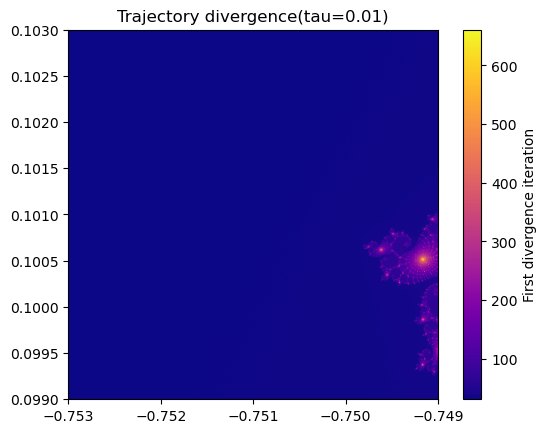

Total pixels: 262144
Number of diverging pixels before max iteration: 262144
Portion Percentage: 100.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N, MAX_ITER, TAU = 512, 1000, 0.01
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any(): 
        break
    
    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]
    diff = (np.abs(z32.real.astype(np.float64) - z64.real)
        + np.abs(z32.imag.astype(np.float64) - z64.imag))
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(diverge, cmap='plasma', origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030])

plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence(tau={TAU})')
plt.show()

# Calculations
total_pixels = N*N
diverged_pixels  = np.sum(diverge < MAX_ITER) # find pixels diverging before max iterations
portion_diverged = diverged_pixels / total_pixels
print(f'Total pixels: {N*N}')
print(f'Number of diverging pixels before max iteration: {diverged_pixels}')
print(f'Portion Percentage: {portion_diverged*100.0:.2f}%')


**Observations to make**

* What fraction of pixels diverge before max iter?

*According to the calculation above, all the pixels diverge before 1000 iterations.*

* Where do trajectories diverge early?

*According to the colormap image above, the earliest divergences appear in the darkest purple areas. The later divergences appear in the red and orange areas of the Mandelbrot plot. In the actual Mandelbrot set, the earliest divergences seem to appear around the edges of the figure.*

* Does early divergence correlate with high escape iteration counts?

*Yes, early divergence correlates with high escape iteration counts. Early trajectory divergence mostly happens near the edges of the Mandelbrot set, which also corresponds to regions with high escape iteration counts*

##### Milestone 2: Mandelbrot Sensitivity Map

eps32: 1.1920928955078125e-07, delta: [[9.05370814e-08 9.05361562e-08 9.05352310e-08 ... 9.00661844e-08
  9.00652593e-08 9.00643342e-08]
 [9.05372030e-08 9.05362779e-08 9.05353527e-08 ... 9.00663067e-08
  9.00653816e-08 9.00644565e-08]
 [9.05373247e-08 9.05363995e-08 9.05354743e-08 ... 9.00664290e-08
  9.00655039e-08 9.00645788e-08]
 ...
 [9.06002188e-08 9.05992943e-08 9.05983698e-08 ... 9.01296517e-08
  9.01287272e-08 9.01278028e-08]
 [9.06003453e-08 9.05994207e-08 9.05984962e-08 ... 9.01297788e-08
  9.01288544e-08 9.01279299e-08]
 [9.06004717e-08 9.05995472e-08 9.05986227e-08 ... 9.01299059e-08
  9.01289815e-08 9.01280570e-08]]


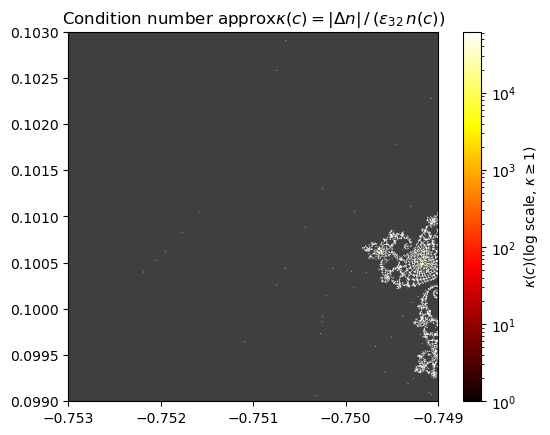

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

print(f'eps32: {eps32}, delta: {delta}')

def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa, cmap=cmap_k, origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030],
        norm=LogNorm(vmin=1, vmax=vmax))

plt.colorbar(label=r'$\kappa(c)$(log scale, $\kappa\geq1$)' )
plt.title(r'Condition number approx$\kappa(c)= |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()


Observations:

* Where is $\kappa$ largest? Does it match the boundary in M1?

*The condition value $\kappa$ value is largest near the edges of the Mandelbrot set. This is highlighted by the hot colormap. The white areas indicate the highest condition values and we can see that the edges are all white on the plot above. This also matches what we observed in M1. Here, the Plasma colormap indicated that the boundaries contained the earliest divergences. This suggests that these areas of the Mandelbrot set are the most sensitive to small changes in the input*

* What is $\kappa$ for interior pixels (n=MAX_ITER)?

*For interior pixels, where n=max_iter, the condition number $\kappa$ is approximately zero. These pixel areas of the Mandelbrot set are the most numerically insensitive. In other words, these areas are not as sensitive to small changes in the input compared to the edges of the Mandelbrot set.*

---

# Testing & Documentation

Setup ipytest

In [ ]:
import ipytest
ipytest.autoconfig()


## Exercises

##### Exercise 1: Extract and Test 41

In [ ]:
import math

def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    z = 0j
    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter

# Naive mandelbrot pixel check method
def naive_mandelbrot(c, max_iteration) -> int:
    # Initialize z value before loop
    z = 0

    for n in range(max_iteration):
        # compute: z_{n+1} = z_n^2 + c
        z = z**2 + c
        # Check if new z value exceeds 2
        if math.sqrt( z.real**2 + z.imag**2 ) > 2:
            return n
    
    # If we reach max_iteration and z has still not diverged, we return max_iteration
    return max_iteration


ipytest output from notebook

In [ ]:
%%ipytest -v

def test_origin():
    assert mandelbrot_pixel(0+0j, 100) == 100
    assert naive_mandelbrot(0+0j, 100) == 100

def test_far_outside():
    assert mandelbrot_pixel(5.0+0j, 100) == 1


======================================= test session starts ========================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items

t_1815c240c9cb409c8df4a0ecc5f21578.py ..                                                     [100%]

======================================== 2 passed in 0.01s =========================================


Output using pytest -v

```python
=============================================================================================== test session starts ===============================================================================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/kimnielsen/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items                                                                                                                                                                                                 

test_mandelbrot_pixel.py::test_origin PASSED                                                                                                                                                                [ 50%]
test_mandelbrot_pixel.py::test_far_outside PASSED                                                                                                                                                           [100%]

================================================================================================ 2 passed in 0.00s ================================================================================================
```

##### Exercise 2: Add a Docstring 42

In [ ]:
def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    """Find the number of iterations for one point in the complex plane.
    
    Iterates z_{n+1} = z_n^2 + c starting from 0 until |z| > 2 or max_iter is reached.
    
    Parameters
    ----------
    c : complex
        Point in the complex plane to check.
    
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns:
    ----------
    int 
        Iteration count if z_{real}^2 + z_{imag}^2 > 4, else max_iter
    """
    z = 0j
    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter


Display method docs with markdown

In [ ]:
from IPython.display import display, Markdown
display(Markdown(mandelbrot_pixel.__doc__))


Find the number of iterations for one point in the complex plane.

    Iterates z_{n+1} = z_n^2 + c starting from 0 until |z| > 2 or max_iter is reached.

    Parameters
    ----------
    c : complex
        Point in the complex plane to check.

    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns:
    ----------
    int 
        Iteration count if z_{real}^2 + z_{imag}^2 > 4, else max_iter
    

##### Exercise 3: Branch Coverage Report

**Generate coverage report with:**

```sh
pytest --cov=. --cov-branch --cov-report=term-missing -v
```

**Coverage report:**

```python
=============================================================================================== test session starts ===============================================================================================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/kimnielsen/miniforge3/envs/nsc2026/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/git/aau-repos/2_semester/nsc-kim-new/mp3
plugins: anyio-4.12.1, cov-7.1.0
collected 2 items                                                                                                                                                                                                 

test_mandelbrot_pixel.py::test_origin PASSED                                                                                                                                                                [ 50%]
test_mandelbrot_pixel.py::test_far_outside PASSED                                                                                                                                                           [100%]

================================================================================================= tests coverage ==================================================================================================
________________________________________________________________________________ coverage: platform darwin, python 3.11.15-final-0 ________________________________________________________________________________

Name                       Stmts   Miss Branch BrPart  Cover   Missing
----------------------------------------------------------------------
mandelbrot_pixel.py           15      1      8      1    91%   22
test_mandelbrot_pixel.py       6      0      0      0   100%
----------------------------------------------------------------------
TOTAL                         21      1      8      1    93%
================================================================================================ 2 passed in 0.01s ================================================================================================
```

## Milestones

##### Milestone 1: Test Suite

###### **Numba**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
import numpy as np
from numba import njit

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
x_min    = -2.0  # min point on real axis
x_max    = 1.0   # max point on real axis
y_min    = -1.5  # min point on imaginary axis
y_max    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.


# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
def mandelbrot_pixel_python(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter


@njit
def mandelbrot_chunk(
    row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter
) -> np.array:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    return mandelbrot_set


def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)


###### **Multiprocessing**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
import psutil
import numpy as np
from numba import njit

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N        = 1024  # Same width & height
x_min    = -2.0  # min point on real axis
x_max    = 1.0   # max point on real axis
y_min    = -1.5  # min point on imaginary axis
y_max    = 1.5   # max point on imaginary axis
max_iter = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.


# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter


@njit
def mandelbrot_chunk(
    row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter
) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    return mandelbrot_set


def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_multiprocessing(N, x_min, x_max, y_min, y_max, max_iter):
    cores = psutil.cpu_count(logical=False)
    for n_workers in range(1, cores + 1):
        chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, x_min, x_max, y_min, y_max, max_iter))
            row = end

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)  # warm-up: Numba JIT in all workers
            for _ in range(3):
                np.vstack(pool.map(_worker, chunks))


###### **Dask**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from dask import delayed
import dask, numpy as np
from numba import njit

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N         = 50  # Same width & height
X_MIN     = -2.0  # min point on real axis
X_MAX     = 1.0   # max point on real axis
Y_MIN     = -1.5  # min point on imaginary axis
Y_MAX     = 1.5   # max point on imaginary axis
max_iter  = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.
n_workers = 4


@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter


@njit(cache=True)
def mandelbrot_chunk(
    row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter
) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    return mandelbrot_set


def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    print(f'N: {N}, n_chunks: {n_chunks}, Chunk sz: {chunk_size}')
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(
            delayed(mandelbrot_chunk)(
                row, row_end, N, x_min, x_max, y_min, y_max, max_iter
            )
        )
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)


###### **test_mandelbrot.py**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from mandelbrot_numba import mandelbrot_pixel # This is the same implementation in all Mandelbrot variants
import mandelbrot_numba
import mandelbrot_multiprocessing
import mandelbrot_dask
import pytest
import numpy as np
from dask.distributed import Client, LocalCluster

# ----------------------------------------------------------------------------------------------------
# Generic Mandelbrot test cases
# ----------------------------------------------------------------------------------------------------
@pytest.mark.parametrize(
    "c_real, c_imag, max_iter, expected",[
        (0.0, 0.0, 100, 100), # Inside the set
        (5.0, 0.0, 100, 1)    # Far outside the set
    ])
def test_mandelbrot_pixel(c_real, c_imag, max_iter, expected):
    """ Check if complex point is inside mandelbrot set or outside """
    assert mandelbrot_pixel(c_real, c_imag, max_iter) == expected

# ----------------------------------------------------------------------------------------------------
# Numba test cases
# ----------------------------------------------------------------------------------------------------
@pytest.mark.parametrize(
    "c_real, c_imag, max_iter, expected",[
        (0.0, 0.0, 100, 100),
        (5.0, 0.0, 100, 1),
    ])
def test_mandelbrot_pixel_identical_behavior(c_real, c_imag, max_iter, expected):
    """ Check that JIT compiled mandelbrot_pixel() matches behavior of pure Python mandelbrot_pixel() """
    assert mandelbrot_numba.mandelbrot_pixel_python(c_real, c_imag, max_iter) == expected
    assert mandelbrot_numba.mandelbrot_pixel(c_real, c_imag, max_iter) == expected

@pytest.mark.parametrize(
    "c_real, c_imag, max_iter",[
        (0.0, 0.0, 100),
        (5.0, 0.0, 100),
        (0.5, 1.0, 100),
    ])
def test_numba_matches_python(c_real, c_imag, max_iter):
    """ Check that JIT compiled mandelbrot_pixel() matches pure Python mandelbrot_pixel() """
    python_result = mandelbrot_numba.mandelbrot_pixel_python(c_real, c_imag, max_iter)
    jit_result    = mandelbrot_numba.mandelbrot_pixel(c_real, c_imag, max_iter)
    assert python_result == jit_result

@pytest.mark.parametrize(
    "N, expected_shape, expected_dtype",[
        (256, (256,256), np.int32),
        (512, (512,512), np.int32),
        (1024, (1024,1024), np.int32)
    ])
def test_numba_shape_dtype(N, expected_shape, expected_dtype):
    """ Check shape and datatype of mandelbrot_serial() """
    result :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    assert result.shape == expected_shape
    assert result.dtype == expected_dtype

def test_numba_chunk_matches_serial():
    """ Check that result from mandelbrot_serial() matches mandelbrot_chunk() """
    N = 512
    serial_result :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    chunk_result  :np.ndarray = mandelbrot_numba.mandelbrot_chunk(0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    assert np.array_equal(serial_result, chunk_result)

def test_numba_deterministic():
    """ Check that mandelbrot_serial() always produces the same result if run twice"""
    N = 512
    result_1 :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    result_2 :np.ndarray = mandelbrot_numba.mandelbrot_serial(N, -2.0, 1.0, -1.5, 1.5, 100)
    assert np.array_equal(result_1, result_2)

# ----------------------------------------------------------------------------------------------------
# Multiprocessing test cases
# ----------------------------------------------------------------------------------------------------
def test_multiprocessing_worker_matches_chunk():
    """ Check that result from mandelbrot_chunk() matches _worker() wrapper result """
    N = 512
    args = (0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    chunk_result  = mandelbrot_multiprocessing.mandelbrot_chunk(*args)
    worker_result = mandelbrot_multiprocessing._worker(args)
    assert np.array_equal(chunk_result, worker_result)

def test_multiprocessing_matches_serial():
    """ Check that multiprocessing mathces serial """
    N = 64
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

def test_multiprocessing_uneven():
    """ Check that multiprocessing can handle an ueven chunk size """
    N = 50
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

@pytest.mark.parametrize(
    "N",[1, 2, 8, 50, 256, 512, 1024])
def test_multiprocessing_vary_N(N):
    """ Check that multiprocessing can handle different resolution sizes """
    args = (-2.0, 1.0, -1.5, 1.5, 100)

    # Serial baseline
    serial_result = mandelbrot_multiprocessing.mandelbrot_chunk(0, N, N, *args)

    # Simulate multiprocessing manually without pool
    n_workers = 4
    chunk_size = max(1, N // n_workers)

    chunks = []
    row = 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, *args))
        row = end
    
    results = [ mandelbrot_multiprocessing._worker(chunk) for chunk in chunks ]
    assembled = np.vstack(results)
    
    assert np.array_equal(serial_result, assembled)

# ----------------------------------------------------------------------------------------------------
# Local Dask test cases
# ----------------------------------------------------------------------------------------------------
@pytest.fixture
def dask_client():
    """ Used to setup local cluster & connect to local Dask client, execute client tasks & terminate connection """
    cluster = LocalCluster(n_workers=2, threads_per_worker=1)
    client = Client(cluster)
    yield client

    # Terminate
    client.close()
    cluster.close()

def test_dask_submit_gather_chunk(dask_client):
    """ Check Dask integration using submit/gather & validating against non Dask execution """
    N = 64
    args = (0, N, N, -2.0, 1.0, -1.5, 1.5, 100)
    future   = dask_client.submit( mandelbrot_dask.mandelbrot_chunk, *args )
    result   = dask_client.gather(future)
    expected = mandelbrot_dask.mandelbrot_chunk(*args)
    assert np.array_equal(result, expected)

def test_dask_mandelbrot_matches_serial(dask_client):
    """ Validate correctness of Dask compute method """
    N = 64
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=4)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)

def test_dask_uneven_chunks(dask_client):
    """ Check if Dask can handle uneven chunk size (e.g. 50/4=12.5) """
    N = 50
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=4)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)

@pytest.mark.parametrize(
    "n_chunks",[1, 2, 32, 100])
def test_dask_various_chunk_sizes(dask_client, n_chunks):
    """ Check that local Dask implementation can handle n_chunks<N, n_chunks=N, n_chunks>N"""
    N = 32
    args = (-2.0, 1.0, -1.5, 1.5, 100)
    dask_result   = mandelbrot_dask.mandelbrot_dask(N, *args, n_chunks=n_chunks)
    serial_result = mandelbrot_dask.mandelbrot_chunk(0, N, N, *args)
    assert np.array_equal(dask_result, serial_result)


**pytest -v**

```python
collected 29 items

test_mandelbrot.py::test_mandelbrot_pixel[0.0-0.0-100-100] PASSED                                                              [  3%]
test_mandelbrot.py::test_mandelbrot_pixel[5.0-0.0-100-1] PASSED                                                                [  6%]
test_mandelbrot.py::test_mandelbrot_pixel_identical_behavior[0.0-0.0-100-100] PASSED                                           [ 10%]
test_mandelbrot.py::test_mandelbrot_pixel_identical_behavior[5.0-0.0-100-1] PASSED                                             [ 13%]
test_mandelbrot.py::test_numba_matches_python[0.0-0.0-100] PASSED                                                              [ 17%]
test_mandelbrot.py::test_numba_matches_python[5.0-0.0-100] PASSED                                                              [ 20%]
test_mandelbrot.py::test_numba_matches_python[0.5-1.0-100] PASSED                                                              [ 24%]
test_mandelbrot.py::test_numba_shape_dtype[256-expected_shape0-int32] PASSED                                                   [ 27%]
test_mandelbrot.py::test_numba_shape_dtype[512-expected_shape1-int32] PASSED                                                   [ 31%]
test_mandelbrot.py::test_numba_shape_dtype[1024-expected_shape2-int32] PASSED                                                  [ 34%]
test_mandelbrot.py::test_numba_chunk_matches_serial PASSED                                                                     [ 37%]
test_mandelbrot.py::test_numba_deterministic PASSED                                                                            [ 41%]
test_mandelbrot.py::test_multiprocessing_worker_matches_chunk PASSED                                                           [ 44%]
test_mandelbrot.py::test_multiprocessing_matches_serial PASSED                                                                 [ 48%]
test_mandelbrot.py::test_multiprocessing_uneven PASSED                                                                         [ 51%]
test_mandelbrot.py::test_multiprocessing_vary_N[1] PASSED                                                                      [ 55%]
test_mandelbrot.py::test_multiprocessing_vary_N[2] PASSED                                                                      [ 58%]
test_mandelbrot.py::test_multiprocessing_vary_N[8] PASSED                                                                      [ 62%]
test_mandelbrot.py::test_multiprocessing_vary_N[50] PASSED                                                                     [ 65%]
test_mandelbrot.py::test_multiprocessing_vary_N[256] PASSED                                                                    [ 68%]
test_mandelbrot.py::test_multiprocessing_vary_N[512] PASSED                                                                    [ 72%]
test_mandelbrot.py::test_multiprocessing_vary_N[1024] PASSED                                                                   [ 75%]
test_mandelbrot.py::test_dask_submit_gather_chunk PASSED                                                                       [ 79%]
test_mandelbrot.py::test_dask_mandelbrot_matches_serial PASSED                                                                 [ 82%]
test_mandelbrot.py::test_dask_uneven_chunks PASSED                                                                             [ 86%]
test_mandelbrot.py::test_dask_various_chunk_sizes[1] PASSED                                                                    [ 89%]
test_mandelbrot.py::test_dask_various_chunk_sizes[2] PASSED                                                                    [ 93%]
test_mandelbrot.py::test_dask_various_chunk_sizes[32] PASSED                                                                   [ 96%]
test_mandelbrot.py::test_dask_various_chunk_sizes[100] PASSED                                                                  [100%]

======================================================== 29 passed in 29.32s ========================================================
```

**pytest --cov=. -v**

```python
========================================================== tests coverage ===========================================================

Name                            Stmts   Miss  Cover
---------------------------------------------------
mandelbrot_dask.py                 41     17    59%
mandelbrot_multiprocessing.py      46     29    37%
mandelbrot_numba.py                42     17    60%
test_mandelbrot.py                118      0   100%
---------------------------------------------------
TOTAL                             247     63    74%
======================================================== 29 passed in 30.20s ========================================================
```

##### Milestone 2: Docstrings and Type Hints

Local Dask Implementation Documented

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from dask import delayed
import dask
import numpy as np
from numba import njit

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N         = 50    # Same width & height
X_MIN     = -2.0  # min point on real axis
X_MAX     = 1.0   # max point on real axis
Y_MIN     = -1.5  # min point on imaginary axis
Y_MAX     = 1.5   # max point on imaginary axis
max_iter  = 100   # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.
n_workers = 4

@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> int:
    """Finds iteration count for a single point in the complex grid.

    Parameters
    ----------
    c_real : float
        Real part of complex point
    c_imag : float
        Imaginary part of complex point
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    int 
        Returns n if it diverges, else max_iter
    """
    
    z_real = z_imag = 0.0

    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if (z_real_sq + z_imag_sq) > 4:
            return n
        z_imag = 2.0 * z_real * z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> np.ndarray:
    """Computes a chunk of the Mandelbrot set

    Parameters
    ----------
    row_start : int
        Starting row
    row_end : int
        Ending row
    N : int
        Size of complex grid
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.

    Returns
    ----------
    np.ndarray 
        (row_end - row_start)xN numpy array
    """
    mandelbrot_set = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N  # Compute normalization factor for real axis
    dy = (y_max - y_min) / N  # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(
                x_min + column * dx, c_imag, max_iter
            )
    
    return mandelbrot_set

def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32) -> np.ndarray:
    """Computes pixel coordinates from index + bounds. We take no arrays as input.
    
    Parameters
    ----------
    N : int
        Size of resolution
    x_min : float
        Minimum point on real axis
    x_max : float
        Maximum point on real axis
    y_min : float
        Minimum point on imaginary axis
    y_max : float
        Maximum point on imaginary axis
    max_iter : int
        The maximum number of iterations if trajectory does not escape.
    n_chunks : int
        Number of chunks to divide complex grid
    
    Returns
    ----------
    np.ndarray 
        2D array of shape (N,N) containing iteration counts
    """

    chunk_size = max(1, N // n_chunks)
    print(f'N: {N}, n_chunks: {n_chunks}, Chunk sz: {chunk_size}')
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(
            delayed(mandelbrot_chunk)(
                row, row_end, N, x_min, x_max, y_min, y_max, max_iter
            )
        )
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)


**Ruff check**

```python
ruff check mandelbrot_dask.py
All checks passed!
```

---

# GPU Computing

## Exercises

##### Exercise 1: **Hello GPU**

In [82]:
"""
basic_test.py — Minimal PyOpenCL installation test for L10.

Run this BEFORE the lecture to confirm PyOpenCL is working:
    python basic_test.py

Expected output:
    Device: <your GPU or CPU device name>
    Kernel output: [1. 4. 9. 16.]
    All elements close? True

If you see an error, see the troubleshooting notes in the L09 slides
or install PoCL (CPU fallback):
    conda install -c conda-forge pyopencl pocl

Adapted from 2024 course template.py.
"""

import numpy as np
import pyopencl as cl

# ---------------------------------------------------------------------------
# 1. Create context and command queue
# ---------------------------------------------------------------------------
ctx   = cl.create_some_context(interactive=False)   # picks first available
queue = cl.CommandQueue(ctx)

dev = ctx.devices[0]
print(f"Device: {dev.name}")
print(f"  Vendor:  {dev.vendor}")
print(f"  OpenCL:  {dev.version}")
print(f"  Compute units: {dev.max_compute_units}")
print()

# ---------------------------------------------------------------------------
# 2. Kernel: square each element of a float32 array
# ---------------------------------------------------------------------------
kernel_source = """
__kernel void square(__global float *a) {
    int i = get_global_id(0);
    a[i] = a[i] * a[i];
}
"""

prog = cl.Program(ctx, kernel_source).build()

# ---------------------------------------------------------------------------
# 3. Allocate host and device buffers
# ---------------------------------------------------------------------------
a_host = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float32)
result  = np.empty_like(a_host)

mf      = cl.mem_flags
a_dev   = cl.Buffer(ctx, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=a_host)

# ---------------------------------------------------------------------------
# 4. Launch kernel
# ---------------------------------------------------------------------------
prog.square(queue, a_host.shape, None, a_dev)

# ---------------------------------------------------------------------------
# 5. Copy result back to host
# ---------------------------------------------------------------------------
cl.enqueue_copy(queue, result, a_dev)
queue.finish()

print("Kernel output:", result)   # Expected: [1. 4. 9. 16.]

# ---------------------------------------------------------------------------
# 6. Verify
# ---------------------------------------------------------------------------
expected = a_host ** 2
ok = np.allclose(result, expected)
print("All elements close?", ok)

if not ok:
    print("MISMATCH! Expected:", expected, "  Got:", result)
    raise SystemExit(1)


Device: NVIDIA GeForce RTX 2080 Ti
  Vendor:  NVIDIA Corporation
  OpenCL:  OpenCL 3.0 CUDA
  Compute units: 68



c:\Users\Kim\miniforge3\envs\nsc2026\Lib\site-packages\pyopencl\__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),


Kernel output: [ 1.  4.  9. 16.]
All elements close? True


##### Exercise 2: **Vector Sum**

###### **Quick implementation that sums two vectors**

In [83]:
import numpy as np
import pyopencl as cl

context = cl.create_some_context()
cmd_queue = cl.CommandQueue(context)

VEC_SIZE = 50_000

a_host = np.random.rand(VEC_SIZE).astype(np.float32)
b_host = np.random.rand(VEC_SIZE).astype(np.float32)
result_host = np.empty_like(a_host)

mf = cl.mem_flags
a_device = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=a_host)
b_device = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=b_host)
result_device = cl.Buffer(context, mf.WRITE_ONLY, a_host.nbytes)

kernel_source = """
__kernel void sum(
    __global const float *a_device,
    __global const float *b_device,
    __global       float *result_device
)
{
    int gid = get_global_id(0);
    result_device[gid] = a_device[gid] + b_device[gid];
}
"""

prog = cl.Program(context, kernel_source).build()
prog.sum(cmd_queue, a_host.shape, None, a_device, b_device, result_device)
cl.enqueue_copy(cmd_queue, result_host, result_device)

print(result_host)


[1.0439675  1.3725634  0.4121239  ... 1.6126933  0.24244088 0.74525905]


###### **opencl_template.py**

In [86]:
#!/usr/bin/env python3
"""
opencl_template.py — Starting point for writing a PyOpenCL kernel.

Replace the vector-add kernel below with your own kernel.
The six steps are the same for every OpenCL program.
"""

import time
import numpy as np
import pyopencl as cl

def vec_sum(vec_sz):
    print(f'Vector size: {vec_sz}')
    
    # --- Step 1: create context and command queue ---
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    print(f"Device: {ctx.devices[0].name}")

    # --- Step 2: prepare host arrays ---
    a_host      = np.random.rand(vec_sz).astype(np.float32)
    b_host      = np.random.rand(vec_sz).astype(np.float32)
    result_host = np.empty_like(a_host)

    # --- Step 3: allocate device buffers and copy input data ---
    mf       = cl.mem_flags
    a_dev    = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=a_host)
    b_dev    = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=b_host)
    res_dev  = cl.Buffer(ctx, mf.WRITE_ONLY, a_host.nbytes)

    # --- Step 4: compile the kernel ---
    # To load from a separate file instead: KERNEL_SRC = open("kernel.cl").read()
    KERNEL_SRC = """
    __kernel void sum(
        __global const float *a,
        __global const float *b,
        __global       float *result)
    {
        int gid = get_global_id(0);
        result[gid] = a[gid] + b[gid];
    }
    """
    prog = cl.Program(ctx, KERNEL_SRC).build()

    # --- Step 5: launch the kernel ---
    t0 = time.perf_counter()
    prog.sum(queue, a_host.shape, None, a_dev, b_dev, res_dev)
    queue.finish()
    elapsed = time.perf_counter() - t0

    # --- Step 6: copy result back to host ---
    cl.enqueue_copy(queue, result_host, res_dev)
    queue.finish()

    # Verify and report
    print(f"Elapsed:  {elapsed*1000:.3f} ms")
    print(f"Correct:  {np.allclose(result_host, a_host + b_host)}") # compare gpu result with cpu result

vec_sum(vec_sz=50_000)
vec_sum(vec_sz=49_999)


Vector size: 50000
Device: NVIDIA GeForce RTX 2080 Ti
Elapsed:  2.164 ms
Correct:  True
Vector size: 49999
Device: NVIDIA GeForce RTX 2080 Ti
Elapsed:  1.577 ms
Correct:  True


* What value does get_global_id(0) return for work-item 42 if global size = (50000,)? *get_global_id(0) returns the global id of the current work-item. If we know that the current work-item is 42, then the function will return 42*

* What happens if you launch with (49999,) instead of (N,)? *If N=50000 and we launch with 49999, then the index range for work items will lie between 0-49998. This means that the last element will not be processed*

* Why must the result buffer use WRITE ONLY and inputs use READ ONLY? *Because we do not need to modify the inputs. We read the input numbers, use them for summing and then write the result to the memory location associated with the result buffer. Also, using these memory restriction flags enables the OpenCL runtime to enforce correct usage upon the developer*

## Milestones

##### Milestone 1: **Mandelbrot Float32 Kernel**

Using device: NVIDIA GeForce RTX 2080 Ti
Float 32 GPU 1024x1024: 0.6 ms


C:\Users\Kim\AppData\Local\Temp\ipykernel_25588\297267242.py:65: RepeatedKernelRetrieval: Kernel 'mandelbrot_f32' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot_f32(queue, (64, 64), None, image_dev,


0.0006449000065913424

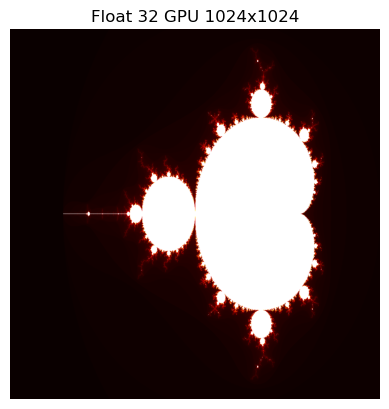

In [ ]:
import pyopencl as cl
import numpy as np
import time
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------------------------------
MAX_ITER     = 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

def do_f32_gpu(N:int, MAX_ITER:int, X_MIN:float, X_MAX:float, Y_MIN:float, Y_MAX:float, do_plot:bool) -> None:
    # ----------------------------------------------------------------------------------------------------
    # Kernel code
    # ----------------------------------------------------------------------------------------------------
    KERNEL_F32 = """
    __kernel void mandelbrot_f32(
        __global int *result,
        const float x_min, const float x_max,
        const float y_min, const float y_max,
        const int N, const int max_iter)
    {
        int col = get_global_id(0);
        int row = get_global_id(1);
        if (col >= N || row >= N) return;   // guard against over-launch

        float c_real = x_min + col * (x_max - x_min) / (float)N;
        float c_imag = y_min + row * (y_max - y_min) / (float)N;
        
        float zr = 0.0f, zi = 0.0f;
        int count = 0;
        while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
            float tmp = zr*zr - zi*zi + c_real;
            zi = 2.0f * zr * zi + c_imag;
            zr = tmp;
            count++;
        }
        result[row * N + col] = count;
    }
    """

    ctx = cl.create_some_context(interactive=False)
    print(f'Using device: {ctx.devices[0].name}')

    queue     = cl.CommandQueue(ctx)
    prog      = cl.Program(ctx, KERNEL_F32).build()
    image     = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    prog.mandelbrot_f32(
        queue, (N, N), None,      # global size (N, N); let OpenCL pick local
        image_dev,
        np.float32(X_MIN), np.float32(X_MAX),
        np.float32(Y_MIN), np.float32(Y_MAX),
        np.int32(N), np.int32(MAX_ITER),
    )

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot_f32(queue, (64, 64), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot_f32(queue, (N, N), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    elapsed = time.perf_counter() - t0

    cl.enqueue_copy(queue, image, image_dev)
    queue.finish()

    print(f"Float 32 GPU {N}x{N}: {elapsed*1e3:.1f} ms")

    if do_plot:
        plt.title(f'Float 32 GPU {N}x{N}'); plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
        plt.savefig("mandelbrot_f32_gpu.png", dpi=150, bbox_inches='tight')

    return elapsed

do_f32_gpu(N=1024, MAX_ITER=MAX_ITER, X_MIN=X_MIN, X_MAX=X_MAX, Y_MIN=Y_MIN, Y_MAX=Y_MAX, do_plot=True)


*GPU f32 runtime*

Float 32 GPU 1024x1024: 0.6 ms 0.6 ms